# Exploratory Analysis (EDA)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/SCMS_Delivery_History_Dataset_reduced.csv", encoding='latin1')

print(df.head())
print(df.shape)
print(df.info())

            Country  Fulfill Via Vendor INCO Term Shipment Mode Product Group  \
0  CÃÂ´te d'Ivoire  Direct Drop              EXW           Air          HRDT   
1           Vietnam  Direct Drop              EXW           Air           ARV   
2  CÃÂ´te d'Ivoire  Direct Drop              FCA           Air          HRDT   
3           Vietnam  Direct Drop              EXW           Air           ARV   
4           Vietnam  Direct Drop              EXW           Air           ARV   

  Sub Classification                                             Vendor  \
0           HIV test                        RANBAXY Fine Chemicals LTD.   
1          Pediatric                           Aurobindo Pharma Limited   
2           HIV test                               Abbott GmbH & Co. KG   
3              Adult  SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...   
4              Adult                           Aurobindo Pharma Limited   

   Line Item Quantity  Line Item Value  Pack Price  Unit Price

In [11]:
df.head()

,Country,Fulfill Via,Vendor INCO Term,Shipment Mode,Product Group,Sub Classification,Vendor,Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD),Delayed
0,CÃÂ´te d'Ivoire,Direct Drop,EXW,Air,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.0,780.34,NaN,0
1,Vietnam,Direct Drop,EXW,Air,ARV,Pediatric,Aurobindo Pharma Limited,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358.0,4521.50,NaN,0
2,CÃÂ´te d'Ivoire,Direct Drop,FCA,Air,HRDT,HIV test,Abbott GmbH & Co. KG,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.0,1653.78,NaN,0
3,Vietnam,Direct Drop,EXW,Air,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.0,16007.06,NaN,0
4,Vietnam,Direct Drop,EXW,Air,ARV,Adult,Aurobindo Pharma Limited,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.0,45450.08,NaN,0


## Missing Values

In [12]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 Country                        0
Fulfill Via                    0
Vendor INCO Term               0
Shipment Mode                  0
Product Group                  0
Sub Classification             0
Vendor                         0
Line Item Quantity             0
Line Item Value                0
Pack Price                     0
Unit Price                     0
Manufacturing Site             0
First Line Designation         0
Weight (Kilograms)             0
Freight Cost (USD)             0
Line Item Insurance (USD)    287
Delayed                        0
dtype: int64


## Target Distribution


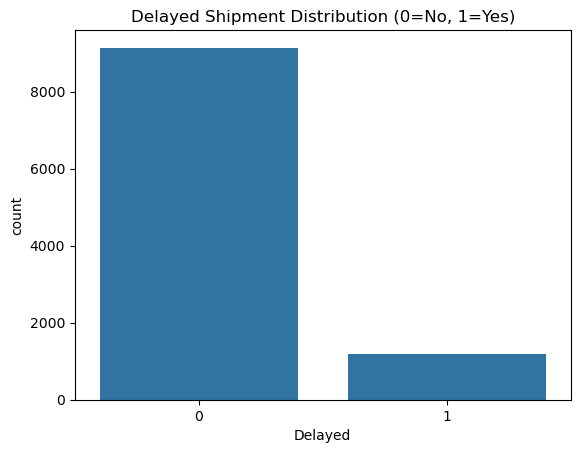

In [9]:
sns.countplot(x='Delayed', data=df)
plt.title('Delayed Shipment Distribution (0=No, 1=Yes)')
plt.show()

## Interval Feature Distributions & Box Plots

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Weight (Kilograms)  10324 non-null  float64
 1   Freight Cost (USD)  10324 non-null  float64
dtypes: float64(2)
memory usage: 161.4 KB
None


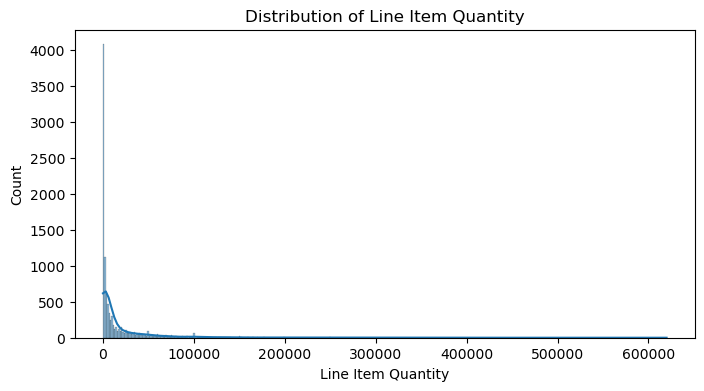

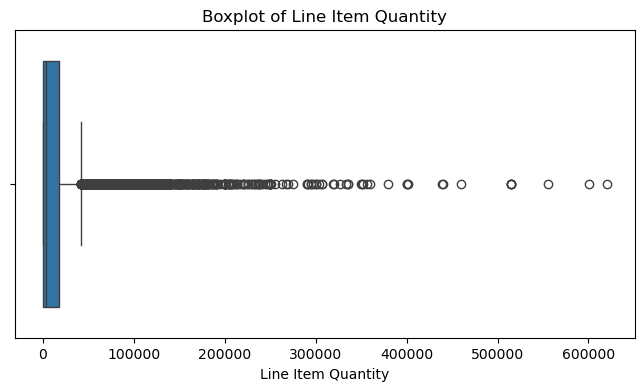

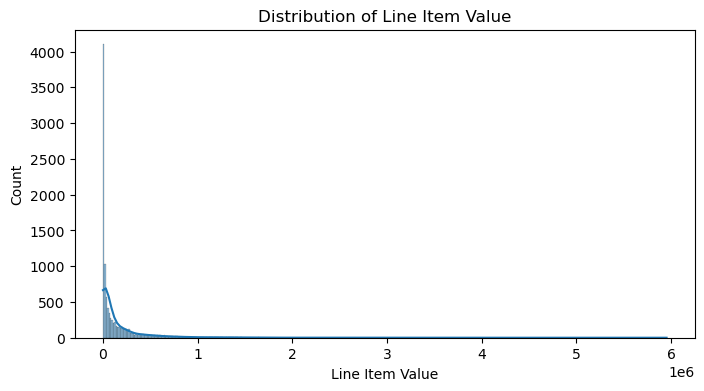

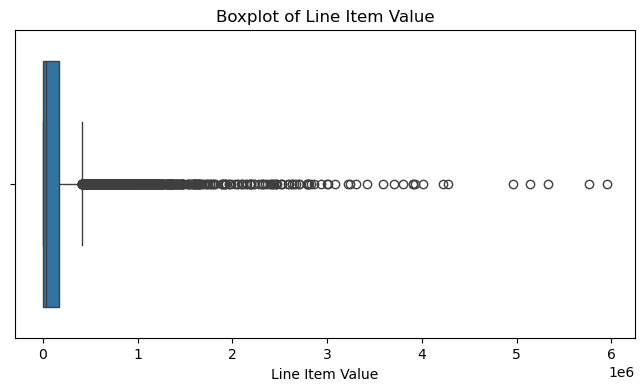

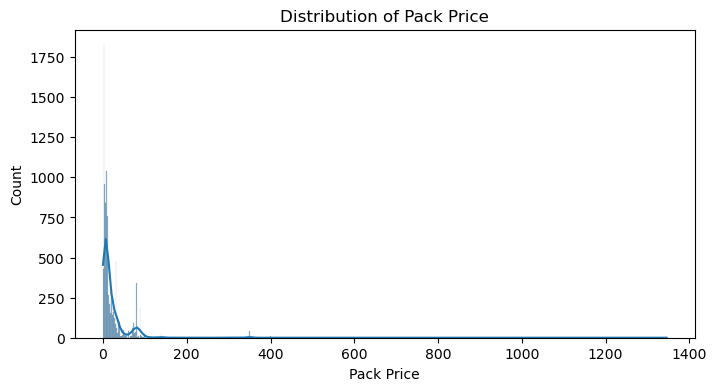

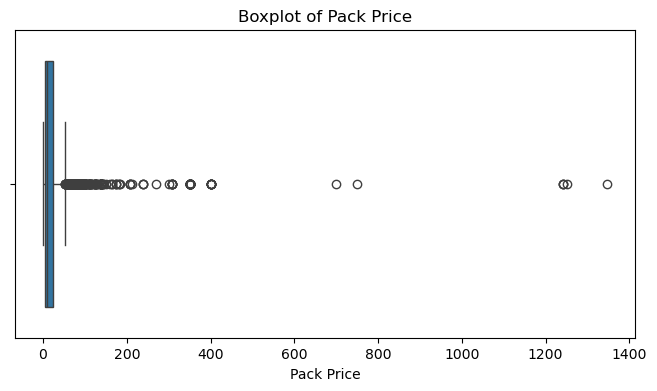

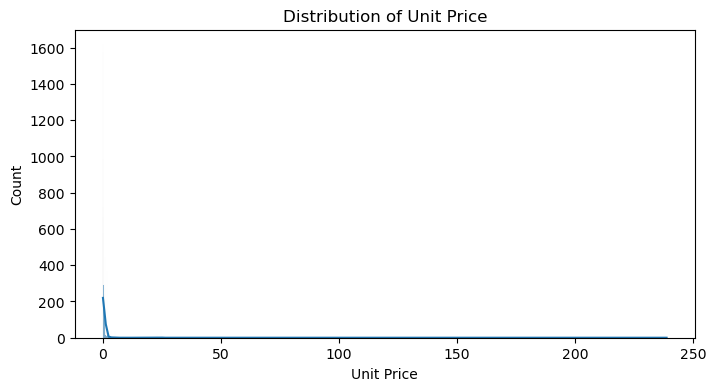

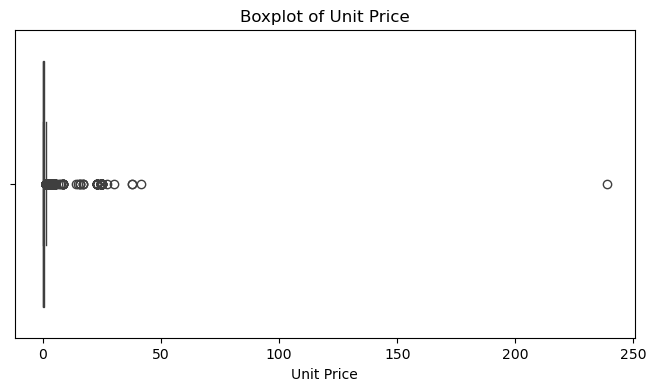

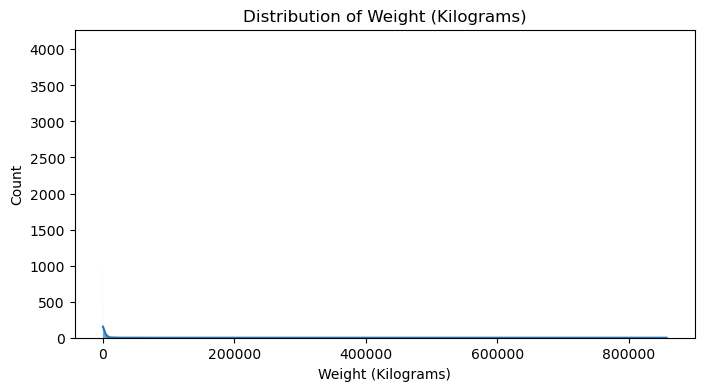

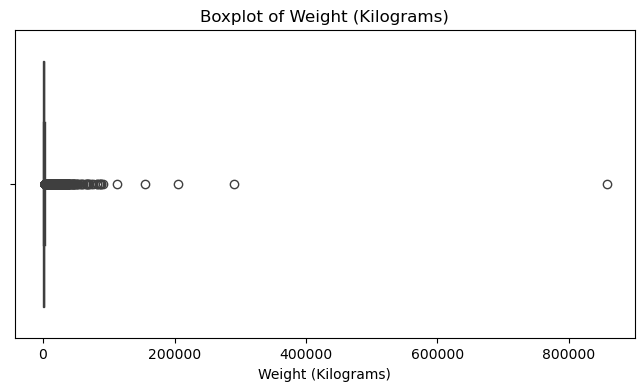

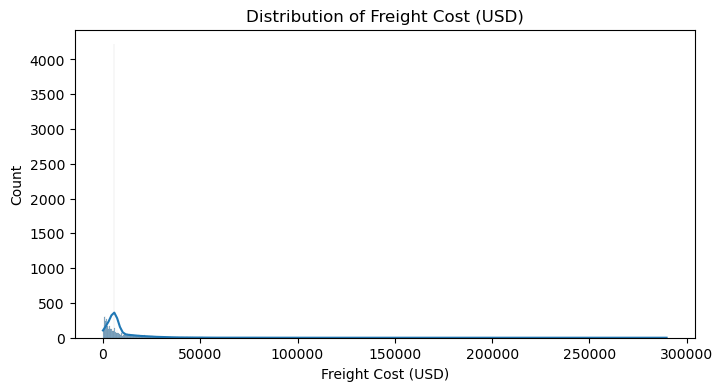

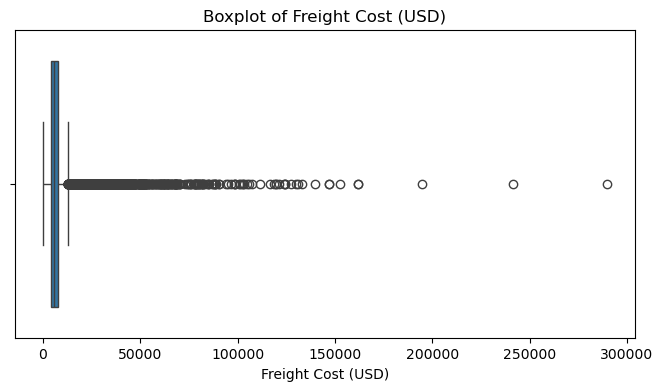

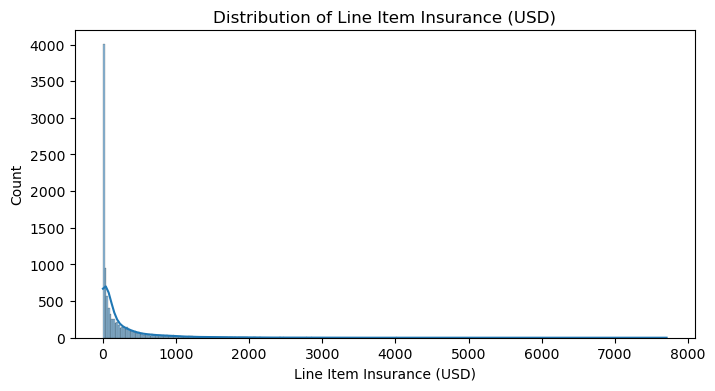

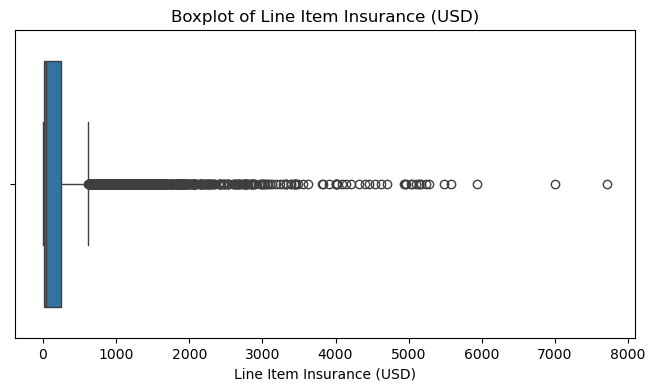

In [16]:
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

print(df[['Weight (Kilograms)', 'Freight Cost (USD)']].info())

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

numeric_cols.remove('Delayed')

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()



## Distribution of Categorical Variables

c:\Users\asus\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


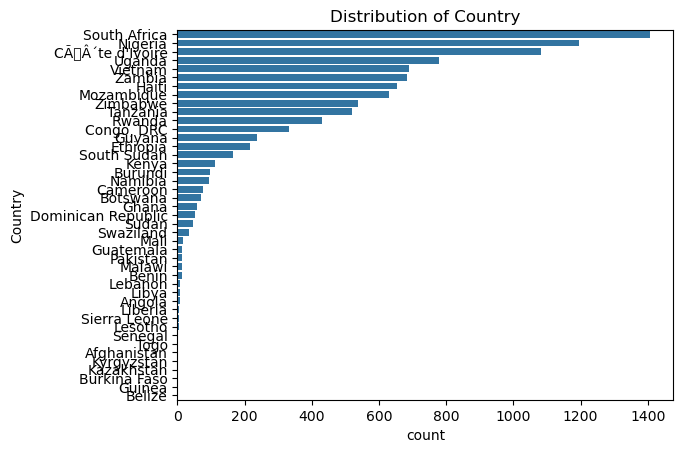

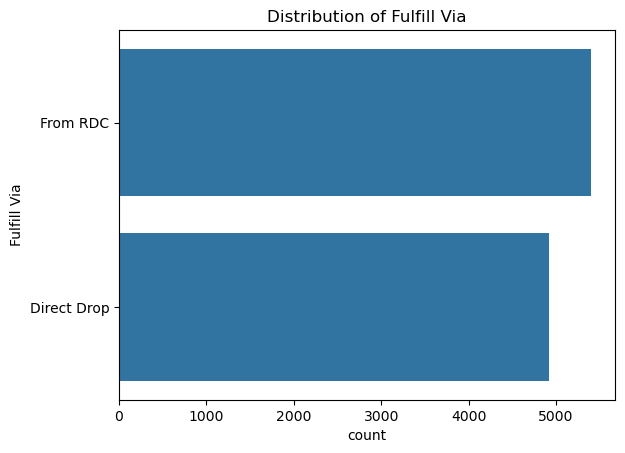

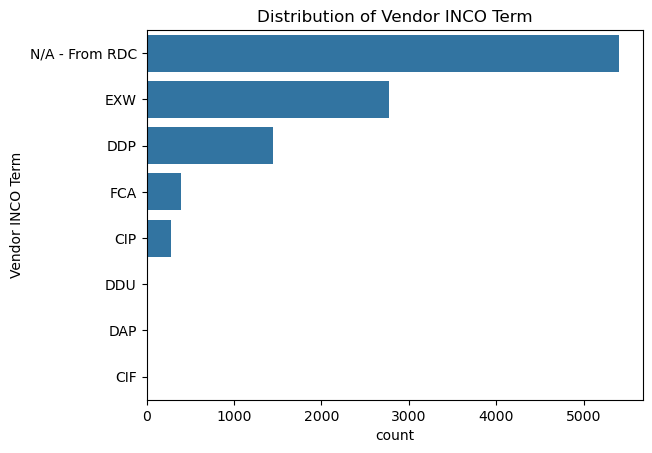

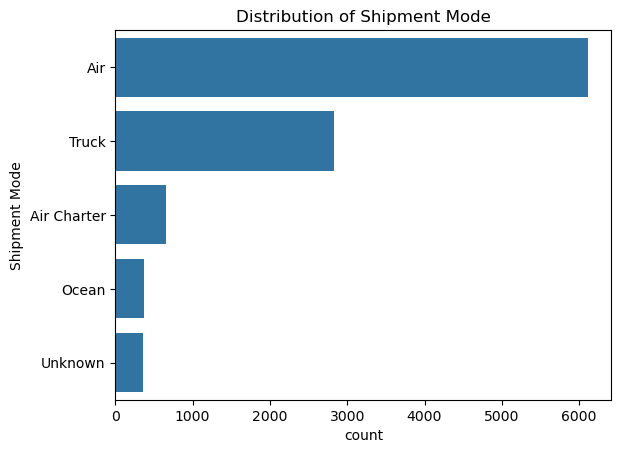

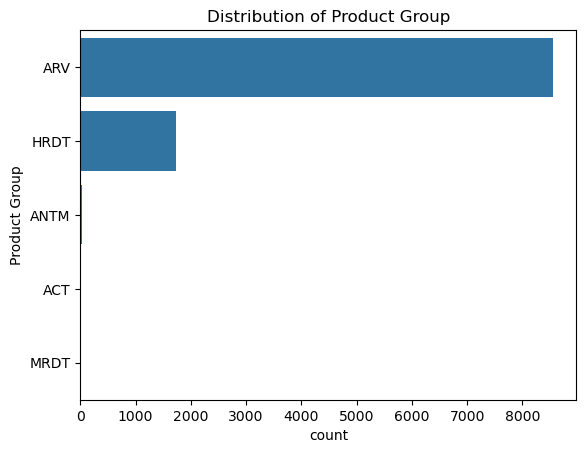

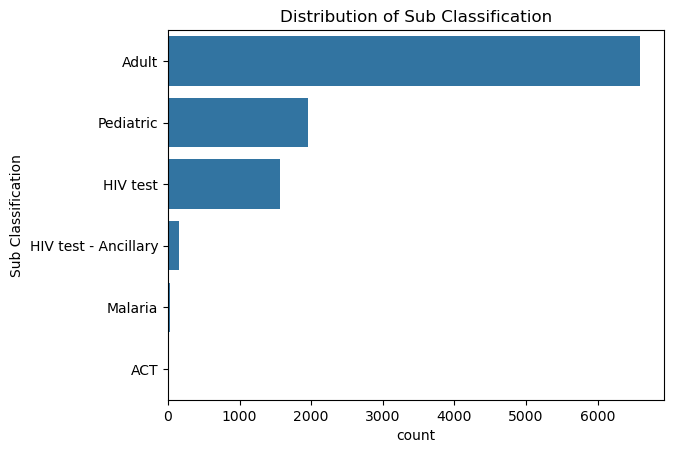

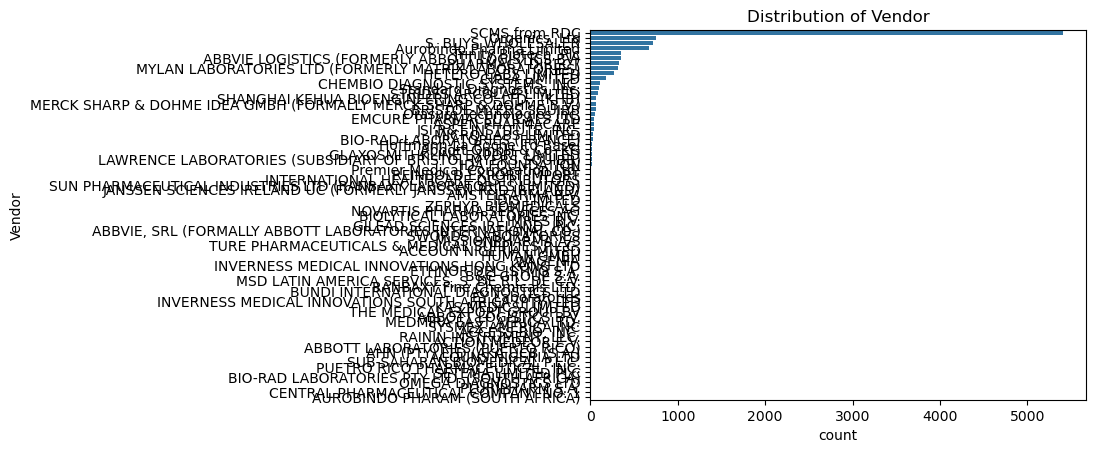

c:\Users\asus\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\asus\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 130 (\x82) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


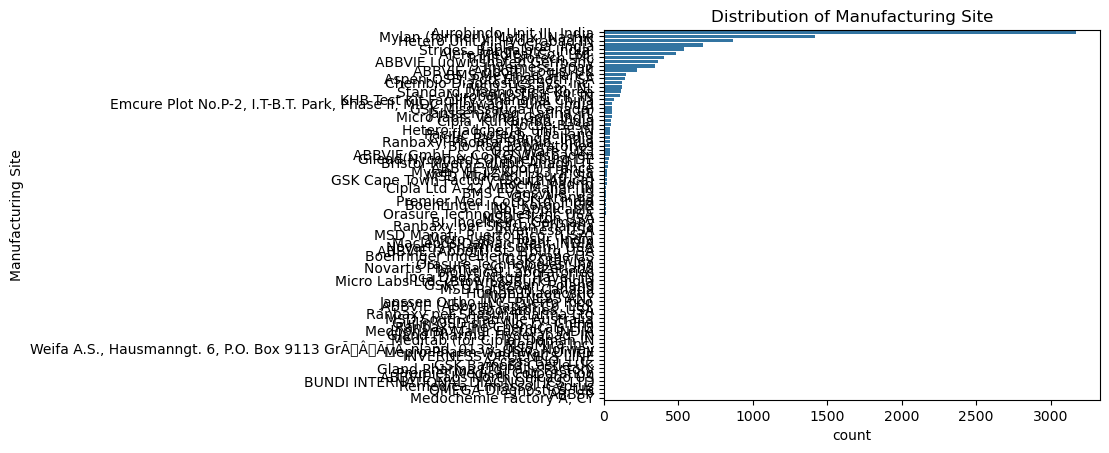

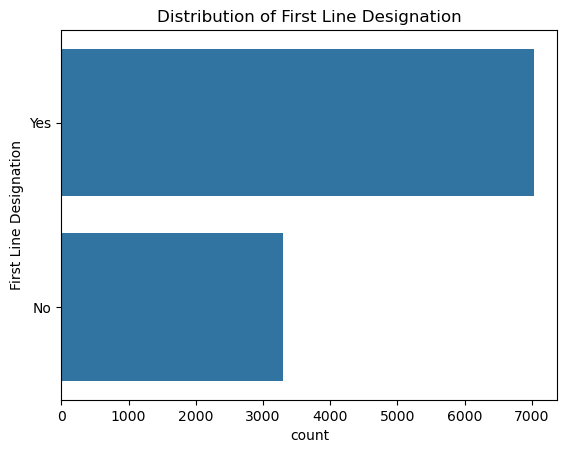

In [17]:
categorical_values = df.select_dtypes(include=['object']).columns
for col in categorical_values:
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

## Analyze Distribution of Target within Variables

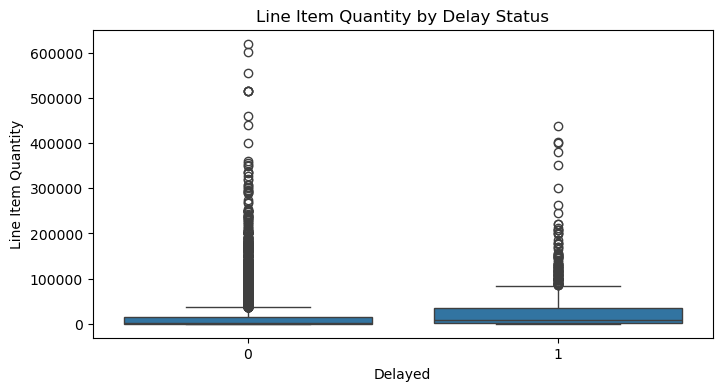

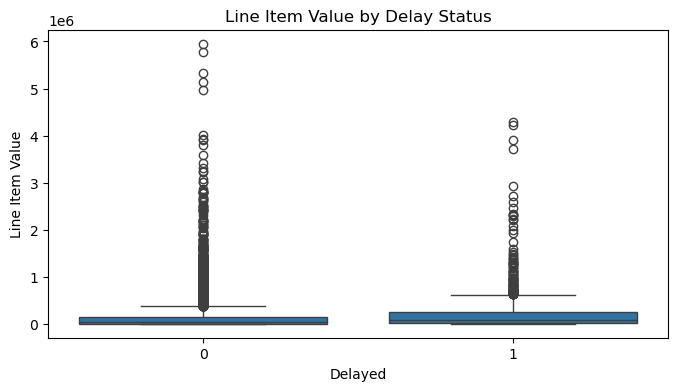

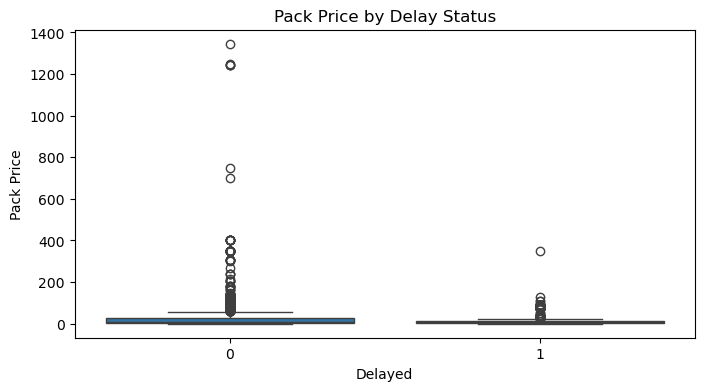

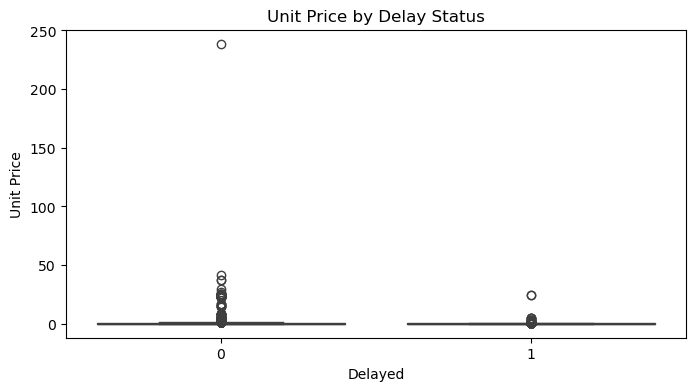

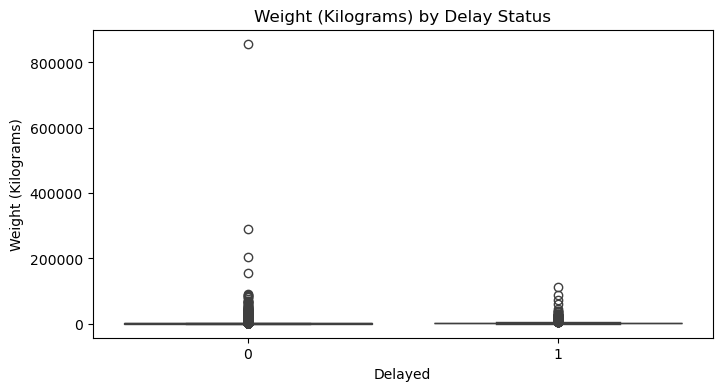

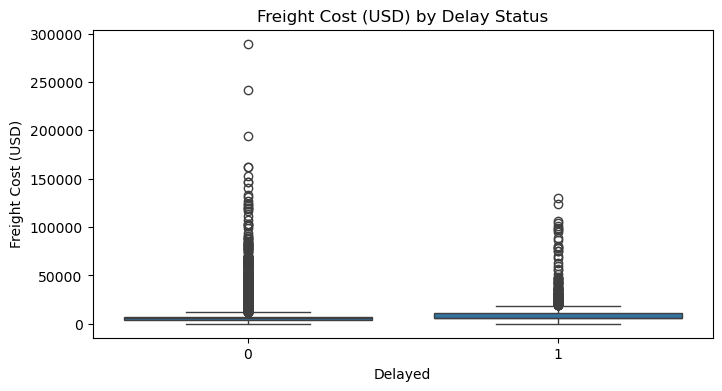

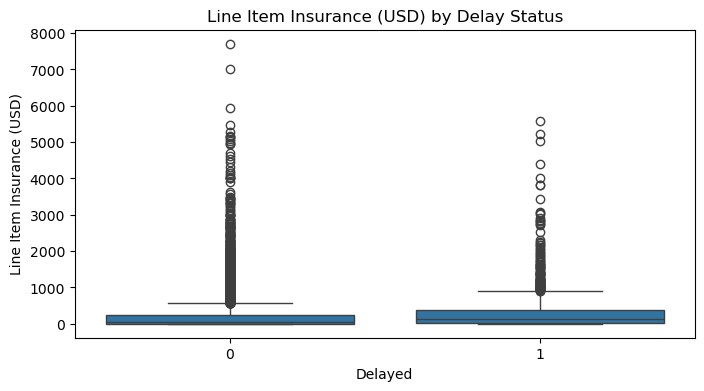

c:\Users\asus\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 131 (\x83) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


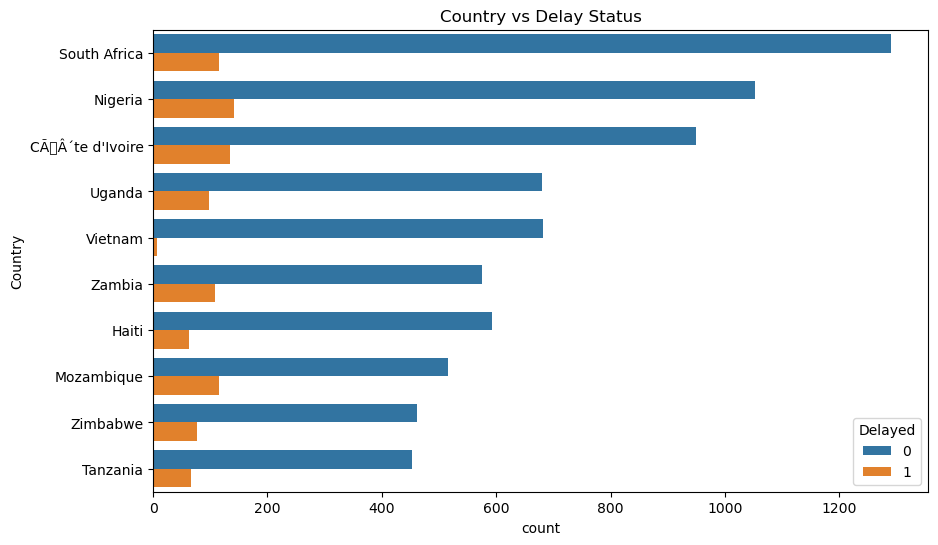

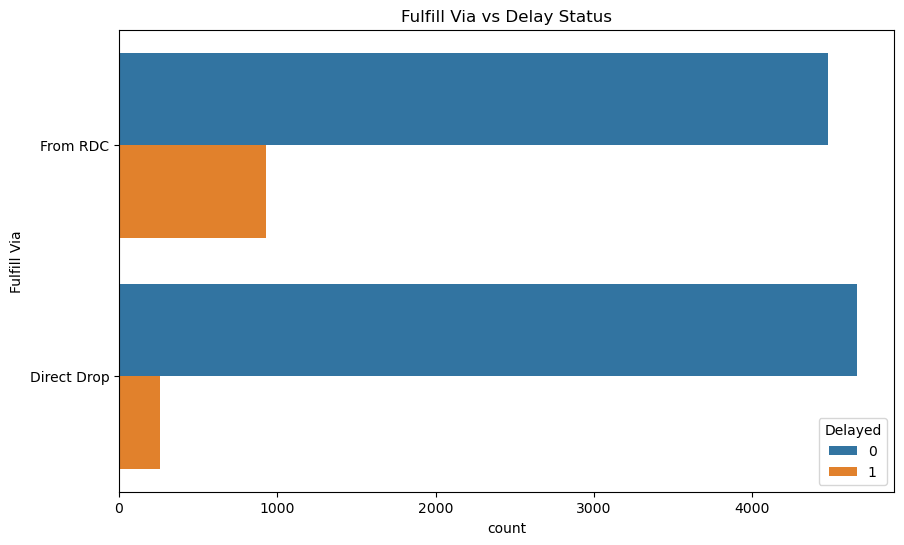

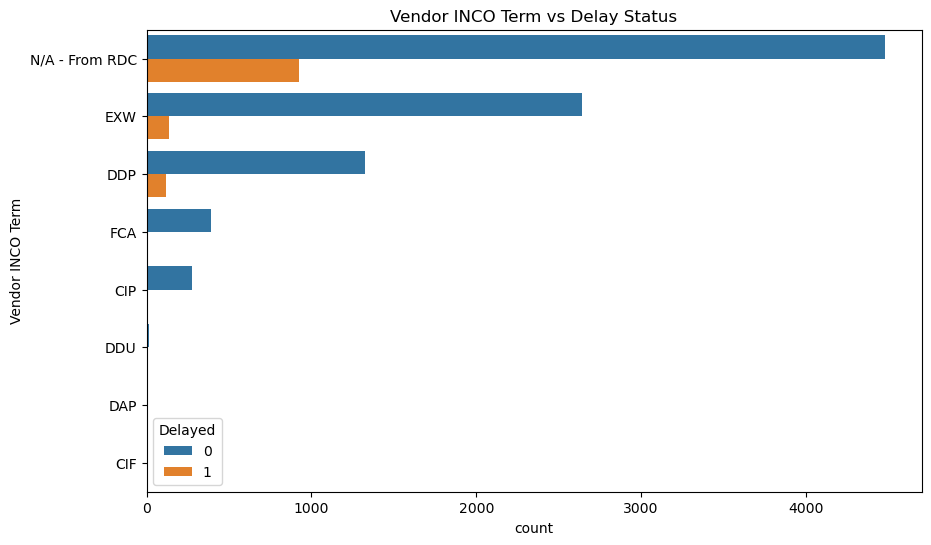

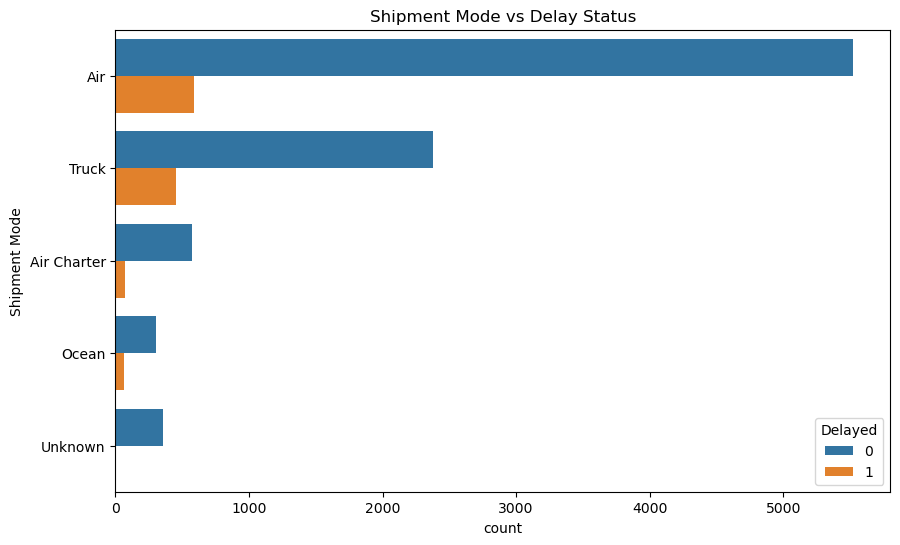

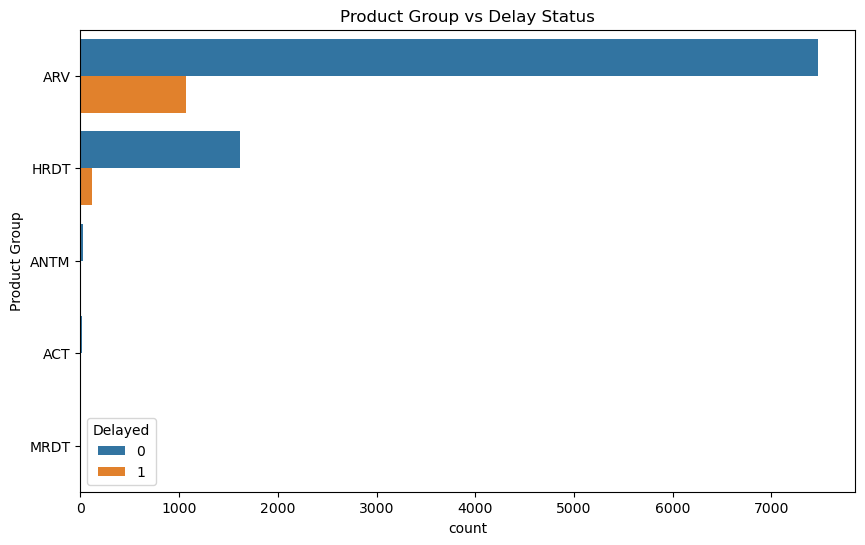

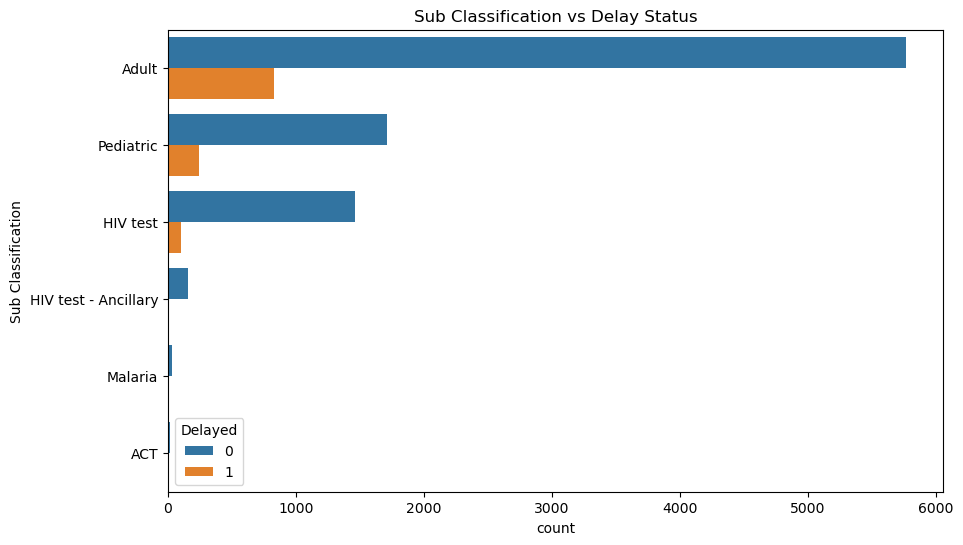

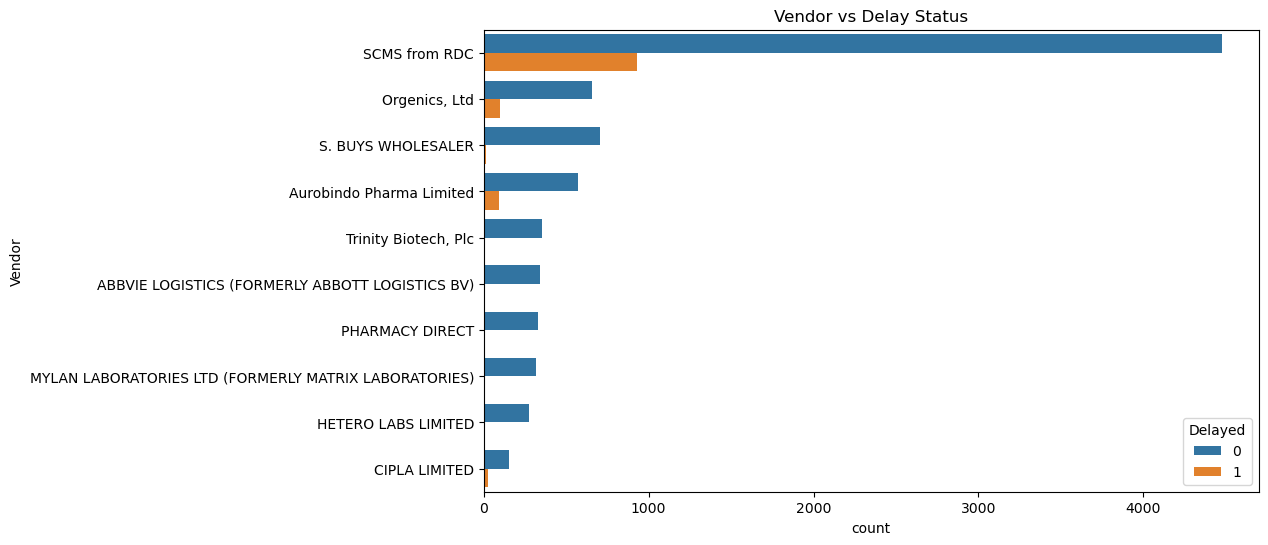

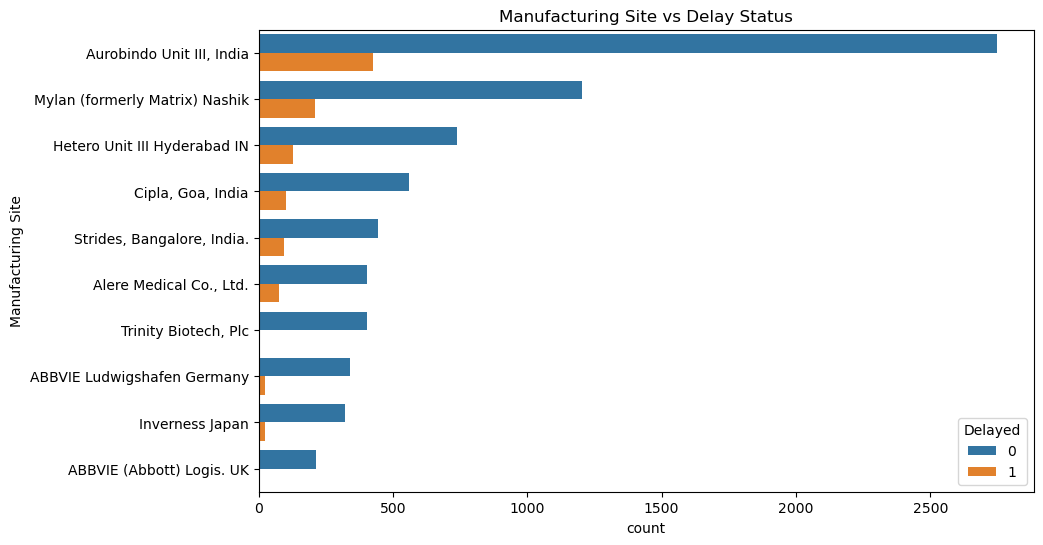

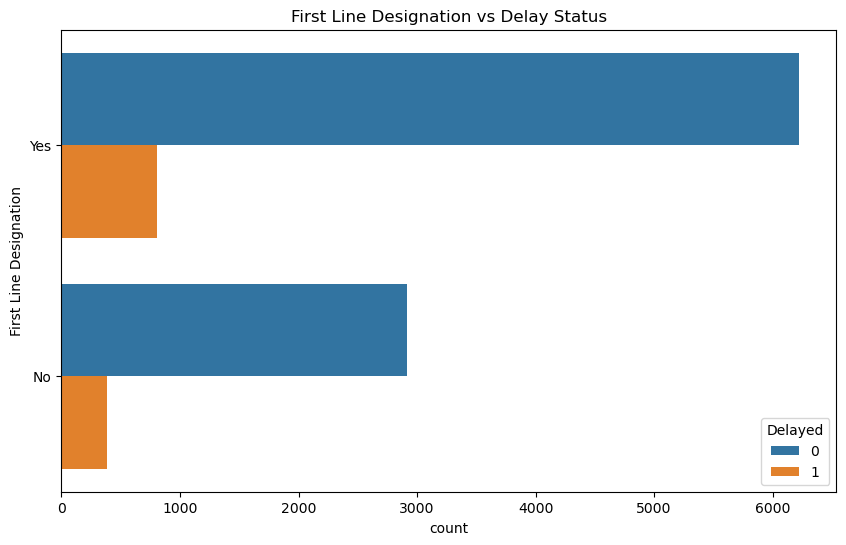

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x='Delayed', y=col, data=df)
    plt.title(f'{col} by Delay Status')
    plt.show()

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=col, hue='Delayed', data=df,
                  order=df[col].value_counts().iloc[:10].index)
    plt.title(f'{col} vs Delay Status')
    plt.show()

## Correlation Map of Interval Variables

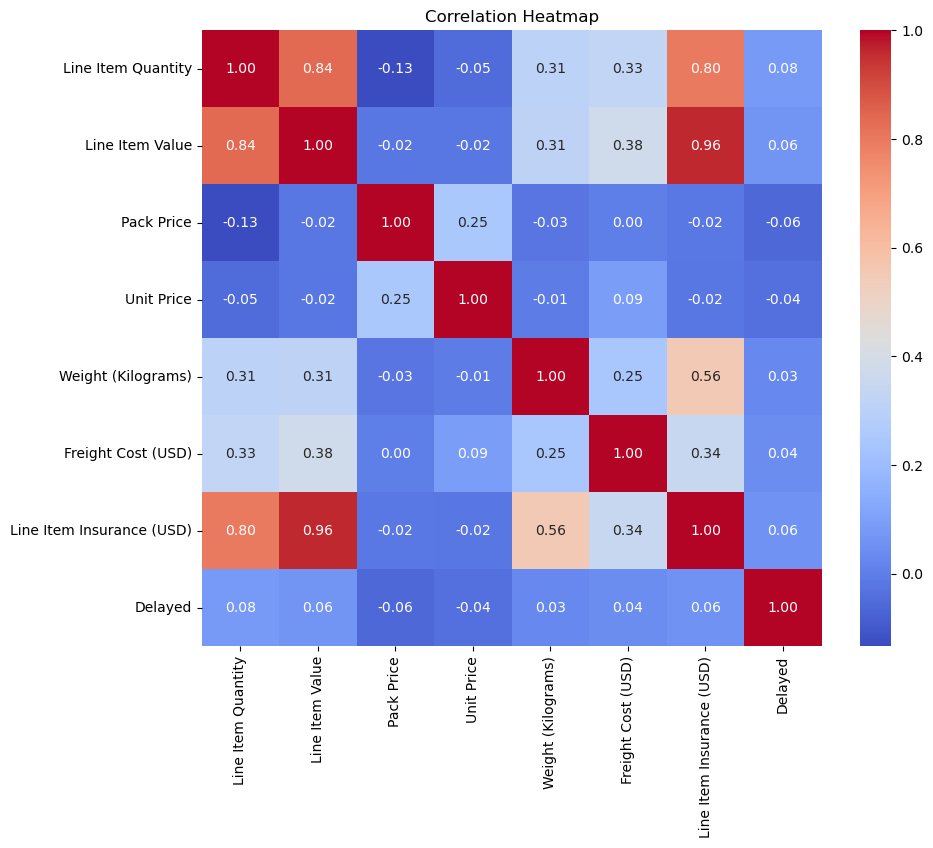

In [20]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols + ['Delayed']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Summary Statistics

In [21]:
import pandas as pd

numeric_cols = df.select_dtypes(include=['number'])

summary_stats = numeric_cols.describe()

skewness = numeric_cols.skew(numeric_only=True)
kurtosis = numeric_cols.kurtosis(numeric_only=True)

summary_df = pd.DataFrame({
    'Mean': numeric_cols.mean(),
    'Median': numeric_cols.median(),
    'Standard Deviation': numeric_cols.std(),
    'Min': numeric_cols.min(),
    'Max': numeric_cols.max(),
    'Skewness': skewness,
    'Kurtosis': kurtosis
})

display(summary_df) 

summary_df.to_csv("summary_statistics.csv")

,Mean,Median,Standard Deviation,Min,Max,Skewness,Kurtosis
Line Item Quantity,18332.534870,3000.000,40035.302961,1.00,619999.00,5.038315,40.050300
Line Item Value,157650.567347,30471.465,345292.066979,0.00,5951990.40,5.837020,54.152430
Pack Price,21.910241,9.300,45.609223,0.00,1345.64,12.988432,293.176204
Unit Price,0.611701,0.160,3.275808,0.00,238.65,40.584849,2725.960252
Weight (Kilograms),2514.363038,1047.000,10689.424697,0.00,857354.00,53.406015,4035.505332
Freight Cost (USD),9011.627852,5869.655,12517.228517,0.75,289653.20,6.150060,68.290551
Line Item Insurance (USD),240.117626,47.040,500.190568,0.00,7708.44,4.827162,34.911215
Delayed,0.114878,0.000,0.318890,0.00,1.00,2.415859,3.837117


## Pairwise Feature Distributions

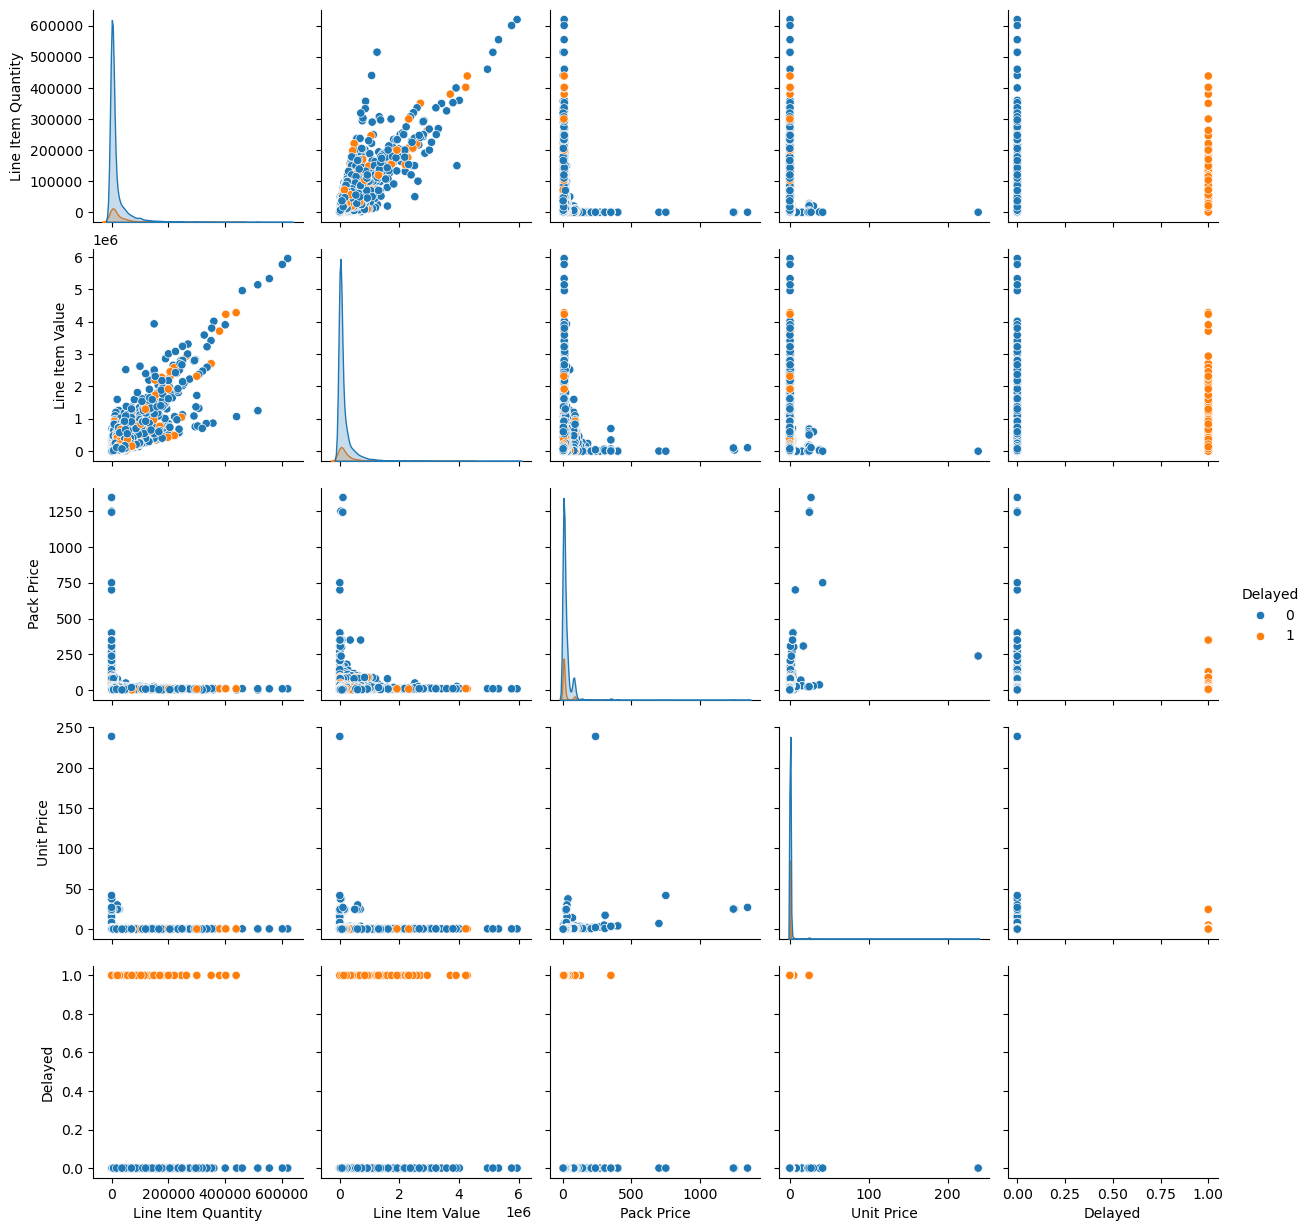

In [22]:
sns.pairplot(df, vars=['Line Item Quantity', 'Line Item Value', 'Pack Price', 'Unit Price', 'Delayed'], hue='Delayed')
plt.show()

## Chi-Squared Tests for Categorical Variables

In [24]:
from scipy.stats import chi2_contingency

categorical_cols = ['Country', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode', 'Vendor', 'Manufacturing Site']
for col in categorical_cols:
    contingency_table = pd.crosstab(df[col], df['Delayed'])
    chi2, p, _, _ = chi2_contingency(contingency_table)
    print(f'{col}: p-value = {p}')

Country: p-value = 2.6091962969053062e-45
Fulfill Via: p-value = 1.348494555981474e-79
Vendor INCO Term: p-value = 8.160697017761194e-79
Shipment Mode: p-value = 1.9485869867591912e-27
Vendor: p-value = 4.7951274735537043e-70
Manufacturing Site: p-value = 1.343497603871741e-31
